In [5]:
!pip install scipy


Sampling Frequency = 40 Hz
Mean Squared Error = 0.2591637218477606


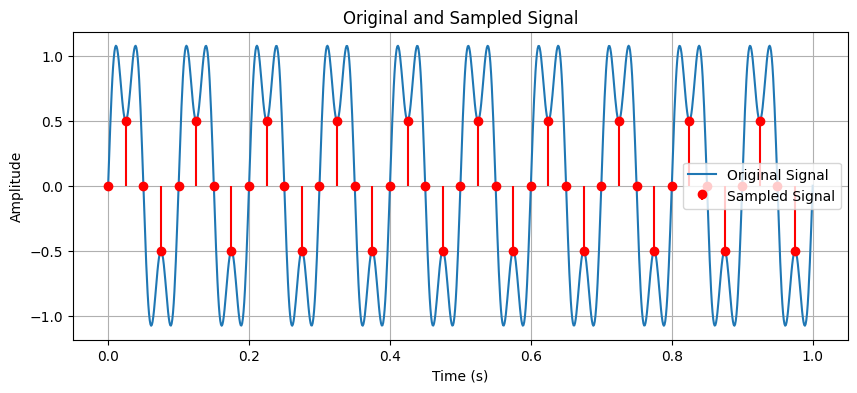

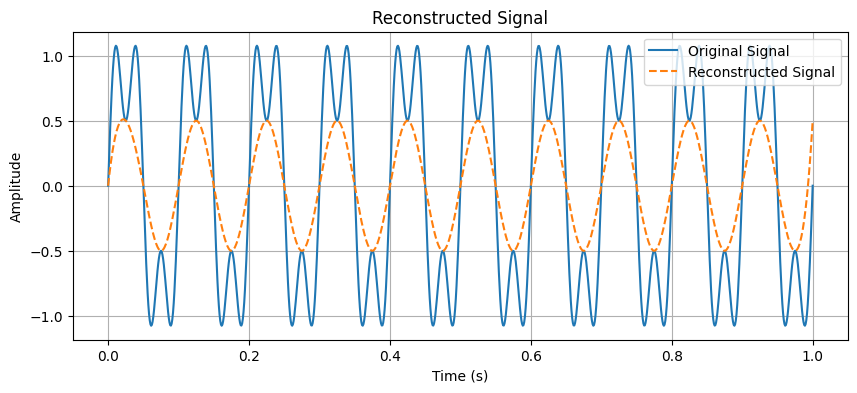

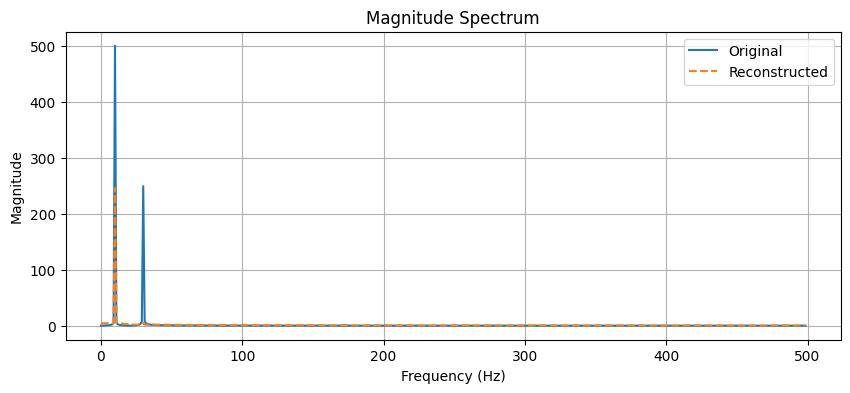

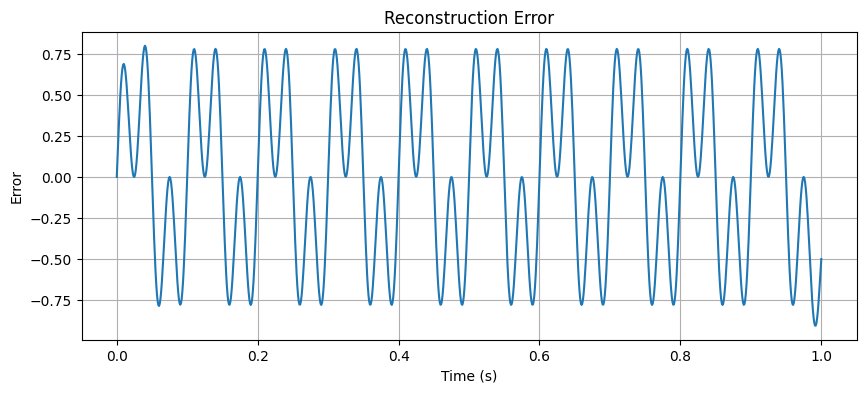

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ===========================
# Original Signal
# ===========================
f1 = 10      # Hz
f2 = 30      # Hz

t = np.linspace(0, 1, 1000)

x = np.sin(2*np.pi*f1*t) + 0.5*np.sin(2*np.pi*f2*t)

# ===========================
# Sampling Frequency
# Change this to:
# 100 -> Above Nyquist
# 60  -> At Nyquist
# 40  -> Below Nyquist
# ===========================
fs = 40

ts = np.arange(0, 1, 1/fs)

xs = np.sin(2*np.pi*f1*ts) + 0.5*np.sin(2*np.pi*f2*ts)

# ===========================
# Reconstruction
# ===========================
reconstruct = interp1d(ts, xs, kind='cubic', fill_value='extrapolate')
xr = reconstruct(t)

# ===========================
# Reconstruction Error
# ===========================
error = x - xr
mse = np.mean(error**2)

print("Sampling Frequency =", fs, "Hz")
print("Mean Squared Error =", mse)

# ===========================
# FFT
# ===========================
X = np.fft.fft(x)
XR = np.fft.fft(xr)

freq = np.fft.fftfreq(len(t), d=t[1]-t[0])

# ===========================
# Plot 1
# ===========================
plt.figure(figsize=(10,4))
plt.plot(t, x, label="Original Signal")
plt.stem(ts, xs, linefmt='r-', markerfmt='ro', basefmt=' ', label="Sampled Signal")
plt.title("Original and Sampled Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()

# ===========================
# Plot 2
# ===========================
plt.figure(figsize=(10,4))
plt.plot(t, x, label="Original Signal")
plt.plot(t, xr, '--', label="Reconstructed Signal")
plt.title("Reconstructed Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()

# ===========================
# Plot 3
# ===========================
plt.figure(figsize=(10,4))
plt.plot(freq[:len(freq)//2], np.abs(X[:len(X)//2]), label="Original")
plt.plot(freq[:len(freq)//2], np.abs(XR[:len(XR)//2]), '--', label="Reconstructed")
plt.title("Magnitude Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.grid(True)
plt.legend()

# ===========================
# Plot 4
# ===========================
plt.figure(figsize=(10,4))
plt.plot(t, error)
plt.title("Reconstruction Error")
plt.xlabel("Time (s)")
plt.ylabel("Error")
plt.grid(True)

plt.show()